# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [149]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [140]:
# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = '.'
zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

# TODO: list CSV files under EXTRACT_DIR
csv_path = 'dataset_heart.csv'  # set to the CSV you choose

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# TODO: inspect df
print(df.head())
print(df.info())
# TODO: identify target column
target = df.columns  # 'target'
print(target)
print(df['heart disease'].value_counts())
# TODO: split features and target
y = df['heart disease'].map({1: 0, 2: 1})  # df[...]
X = df.drop(columns=['heart disease'])  # df.drop(columns=[...])

# TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
# Hint: train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


   age  sex   chest pain type  resting blood pressure  serum cholestoral  \
0   70     1                4                     130                322   
1   67     0                3                     115                564   
2   57     1                2                     124                261   
3   64     1                4                     128                263   
4   74     0                2                     120                269   

   fasting blood sugar  resting electrocardiographic results  max heart rate  \
0                    0                                     2             109   
1                    0                                     2             160   
2                    0                                     0             141   
3                    0                                     0             105   
4                    0                                     2             121   

   exercise induced angina  oldpeak  ST segment  major vessels

### Basic visual checks

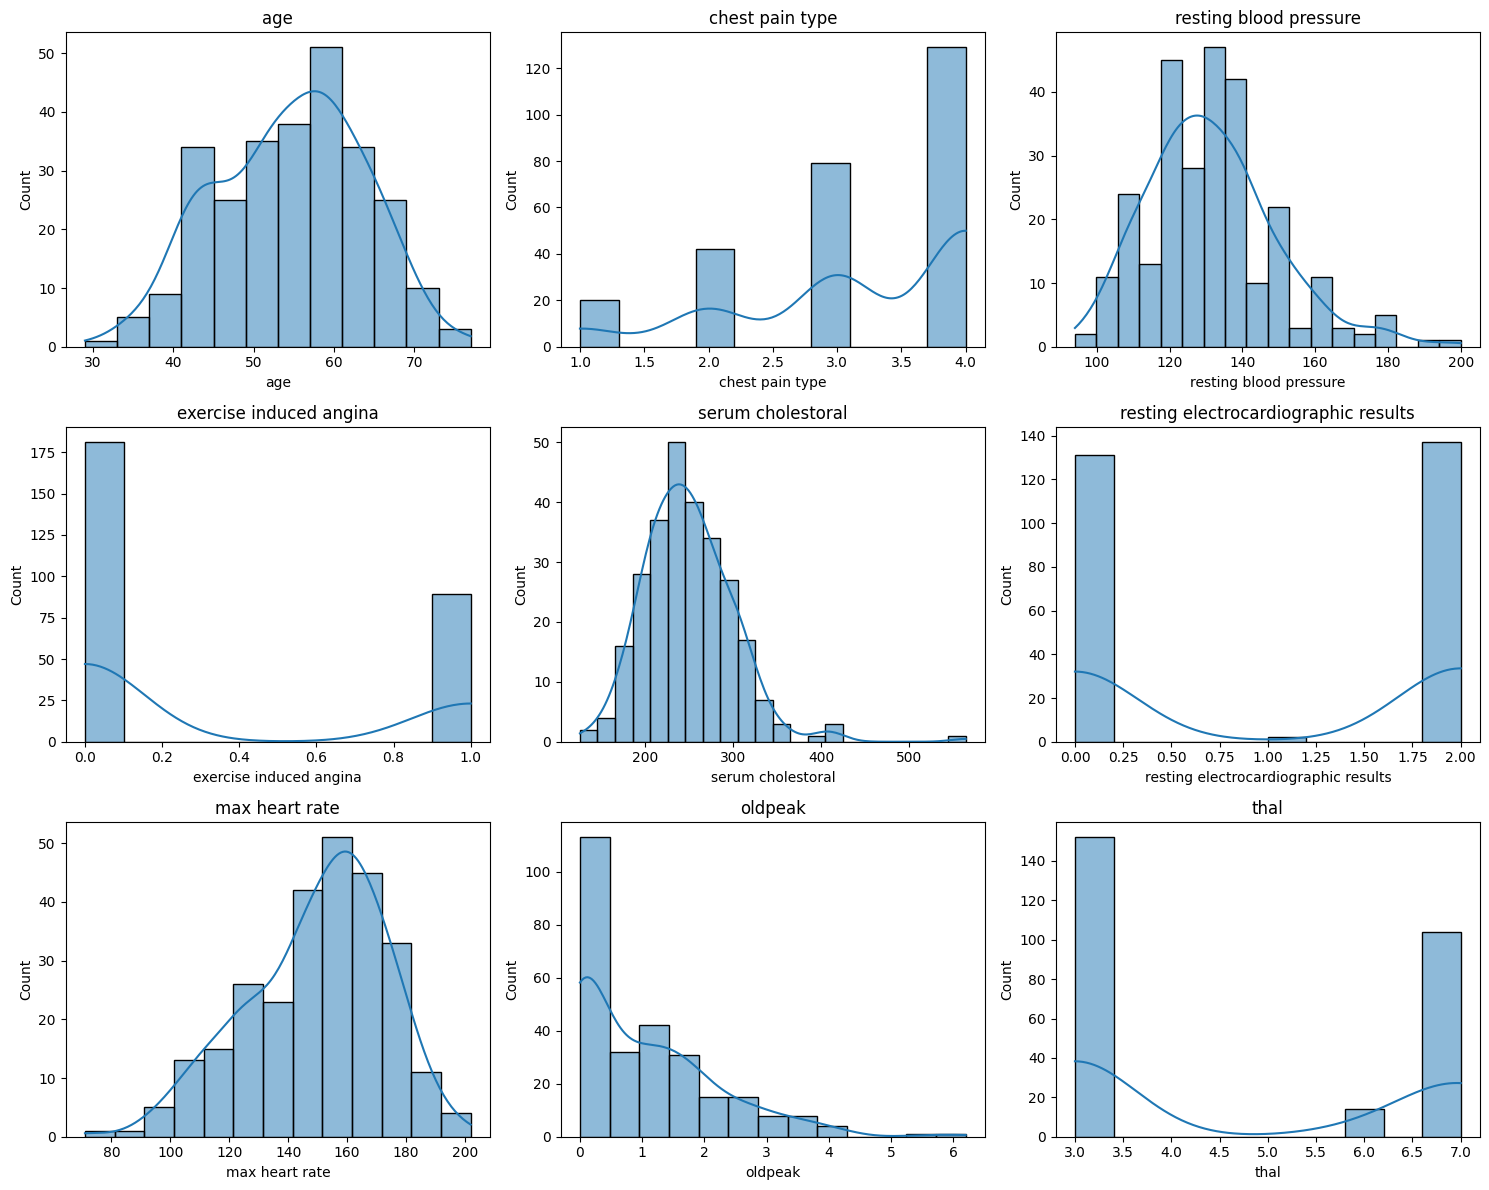

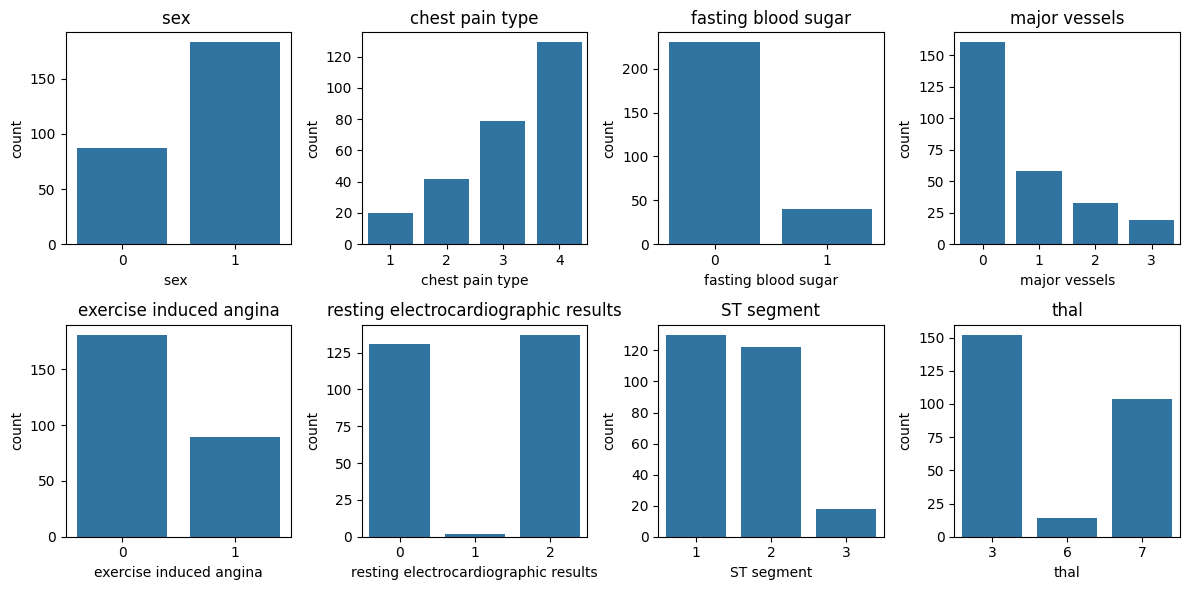

In [141]:
# TODO: pick a few numeric columns and plot histograms
cols = ['age', 'chest pain type', 'resting blood pressure', 'exercise induced angina', 'serum cholestoral', 'resting electrocardiographic results', 'max heart rate', 'oldpeak', 'thal']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(X[col], kde=True, ax=ax)
    ax.set_title(col)
    
plt.tight_layout()
plt.show()

# TODO: plot class balance as a bar chart
bar_cols = ['sex ', 'chest pain type', 'fasting blood sugar', 'major vessels', 'exercise induced angina', 'resting electrocardiographic results','ST segment', 'thal']
fig2, axes2 = plt.subplots(2, 4, figsize=(12, 6))
for ax2, bar_col in zip(axes2.flatten(), bar_cols):
    sns.countplot(x=bar_col, data=X, ax=ax2)
    ax2.set_title(bar_col)
plt.tight_layout()
plt.show()



## Preprocessing pipeline

The idea is to separate columns by type so you can apply different transformations to each:

- num_cols → apply StandardScaler (normalize numeric values to same scale)
- cat_cols → apply OneHotEncoder (convert categories to 0/1 columns)

All columns are already numeric, but some of those numeric columns are actually categorical (just encoded as numbers):

- sex (0/1) — binary category
- chest pain type (0-3) — 4 categories, not a continuous scale
- fasting blood sugar (0/1) — binary
- thal (0-3) — categories


In [142]:
cat_cols = ['chest pain type', 'major vessels', 'resting electrocardiographic results', 'ST segment', 'thal']  # list of object, category, or bool columns
num_cols = ['age', 'resting blood pressure','serum cholestoral', 'max heart rate', 'oldpeak' ]  # list of numeric columns

# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(), cat_cols)
])

X_train_pre = pd.DataFrame(pre.fit_transform(X_train), columns=pre.get_feature_names_out())
X_test_pre = pd.DataFrame(pre.transform(X_test), columns=pre.get_feature_names_out())

print(X_train_pre.head())


   num__age  num__resting blood pressure  num__serum cholestoral  \
0 -1.336180                    -0.637952               -0.762981   
1 -0.039034                    -0.522736                0.732412   
2 -0.363321                    -0.637952                0.907198   
3  1.582397                     0.514202               -0.180361   
4 -0.039034                    -0.637952                0.188632   

   num__max heart rate  num__oldpeak  cat__chest pain type_1  \
0             1.007469     -0.939241                     0.0   
1            -1.551103      1.937160                     0.0   
2             0.289273     -0.399916                     0.0   
3             0.019950      0.678734                     1.0   
4            -0.159599     -0.579691                     0.0   

   cat__chest pain type_2  cat__chest pain type_3  cat__chest pain type_4  \
0                     0.0                     1.0                     0.0   
1                     0.0                     0.0   

## Helper - evaluation function

In [143]:
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)  # model.predict(...)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred), 4),
        'recall': round(recall_score(y_test, y_pred), 4),
        'f1': round(f1_score(y_test, y_pred), 4),
    }
    print(name, metrics)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # TODO: confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(ax=ax1)
    ax1.set_title(f'{name} - Confusion Matrix')
    # Hint: confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay

    # TODO: ROC curve if model has predict_proba
    if hasattr(model, 'predict_proba'):
        y_proba =  model.predict_proba(X_test)[:, 1] # probability
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        metrics['roc_auc'] = roc_auc 
        ax2.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
        ax2.plot([0, 1], [0, 1], 'k--')  # random classifier line
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title(f'{name} - ROC curve')
        ax2.legend()

    return metrics


## Exercise 2 - Logistic Regression without Grid Search

Logistic regression {'accuracy': 0.8519, 'precision': 0.7857, 'recall': 0.9167, 'f1': 0.8462}


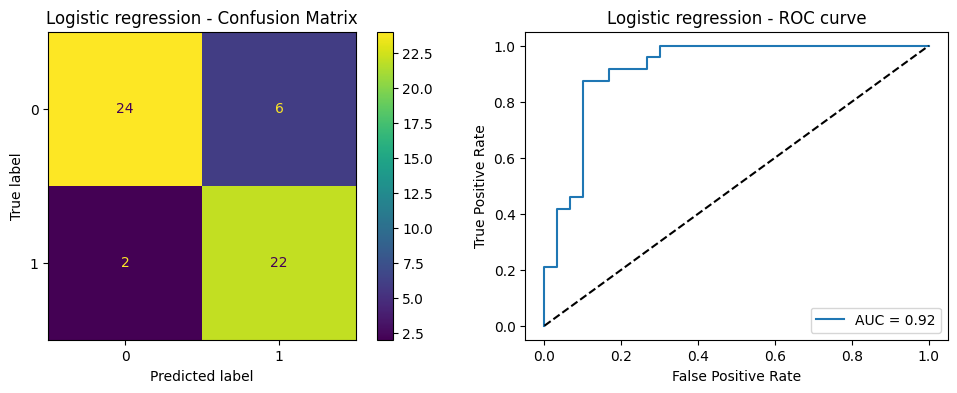

In [144]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
lr = LogisticRegression()

# TODO: fit on training data
lr.fit(X_train_pre, y_train)
# y_pred_lr = pipe_lr.predict(X_test_pre)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report('Logistic regression', lr, X_test_pre, y_test)



## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.1, 'lr__l1_ratio': 0.5, 'lr__max_iter': 10, 'lr__solver': 'saga'}
LR grid {'accuracy': 0.8519, 'precision': 0.8077, 'recall': 0.875, 'f1': 0.84}


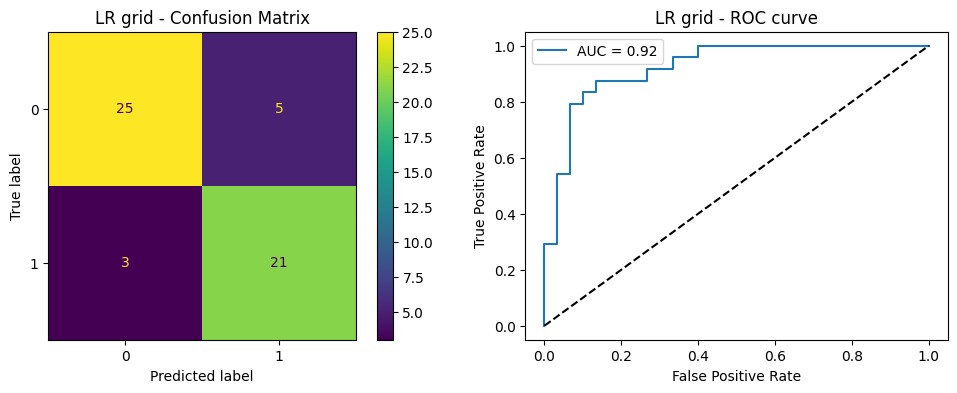

In [145]:
# TODO: build a Pipeline same as above
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pipe_lr_cv = Pipeline([('lr', LogisticRegression())])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__l1_ratio': [0, 0.5, 1],  # 0=l2, 1=l1
    'lr__solver': ['saga'],
    'lr__max_iter': [10, 100, 500, 1000]
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1',)
grid_lr.fit(X_train_pre, y_train)
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test_pre, y_test)


## Exercise 4 - SVM without Grid Search

SVM no grid {'accuracy': 0.8889, 'precision': 0.8462, 'recall': 0.9167, 'f1': 0.88}


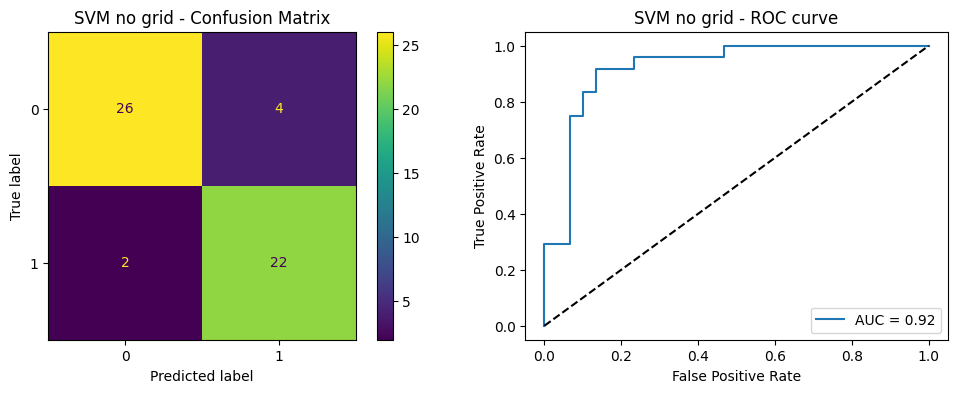

In [146]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
svm = SVC(C=1.0, kernel='rbf', gamma='scale', probability=True, random_state=42)
svm.fit(X_train_pre, y_train)
svm_no_metrics = eval_and_report('SVM no grid', svm, X_test_pre, y_test)


## Exercise 5 - SVM with Grid Search

Best params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
SVM grid {'accuracy': 0.8519, 'precision': 0.7857, 'recall': 0.9167, 'f1': 0.8462}


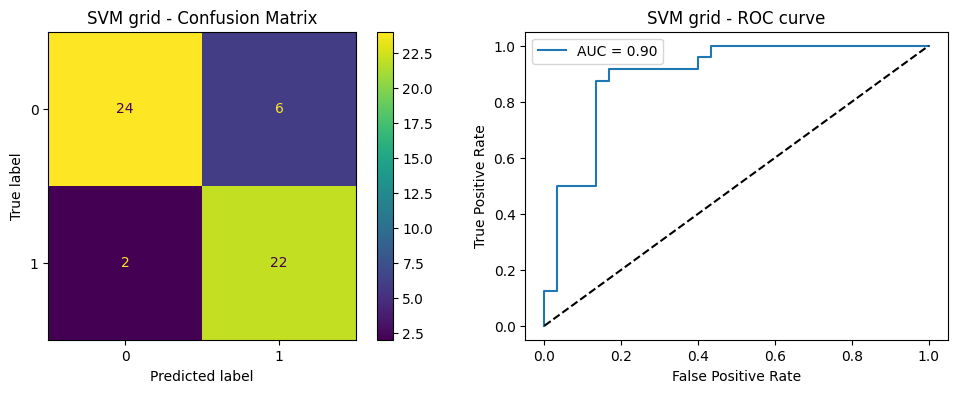

In [147]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
svm_cv = SVC(probability=True)

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'kernel': ['rbf','linear'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'gamma': ['scale','auto'],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(svm_cv, svm_param_grid, cv=5, scoring='f1')
grid_svm.fit(X_train_pre, y_train)
print('Best params:', grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test_pre, y_test)


a few reasons why grid search can give worse test results:

1. Overfitting to the cross-validation folds
GridSearch picks the best params on training cross-validation folds. Those params may not generalize perfectly to the test set. Your default C=1, kernel='rbf' happened to generalize better.

2. Small dataset variance
With a small dataset like heart disease (~300 rows), CV results are noisy — a few samples difference in a fold can change the "best" params.

3. Your default was already near-optimal
C=1, rbf, scale is often a strong default for SVM. GridSearch just confirmed it's in the right ballpark but picked a slightly different combination that CV preferred.

This is why you should always compare on the test set and not blindly trust grid search results — the default can sometimes win.

## Exercise 6 - XGBoost without Grid Search

XGB no grid {'accuracy': 0.7963, 'precision': 0.7407, 'recall': 0.8333, 'f1': 0.7843}


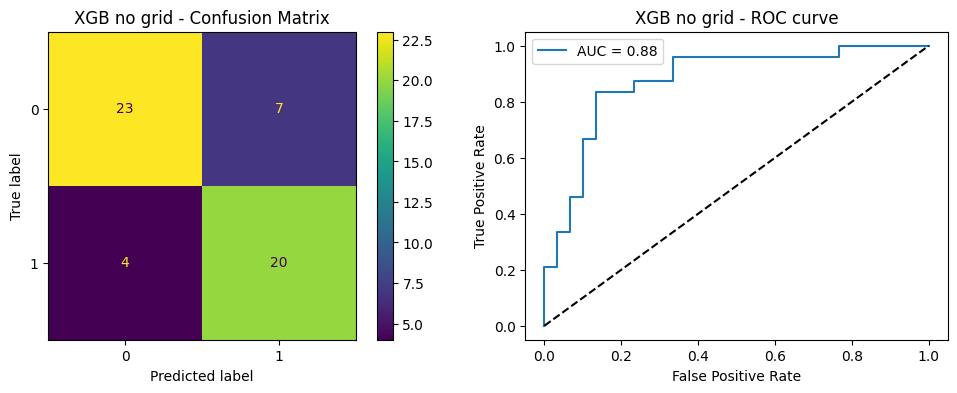

In [153]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE)
xgb.fit(X_train_pre, y_train)
xgb_no_metrics = eval_and_report('XGB no grid', xgb, X_test_pre, y_test)


## Exercise 7 - XGBoost with Grid Search

Best params:  {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.5, 'xgb__max_depth': 5, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
XGB grid {'accuracy': 0.8148, 'precision': 0.7692, 'recall': 0.8333, 'f1': 0.8}


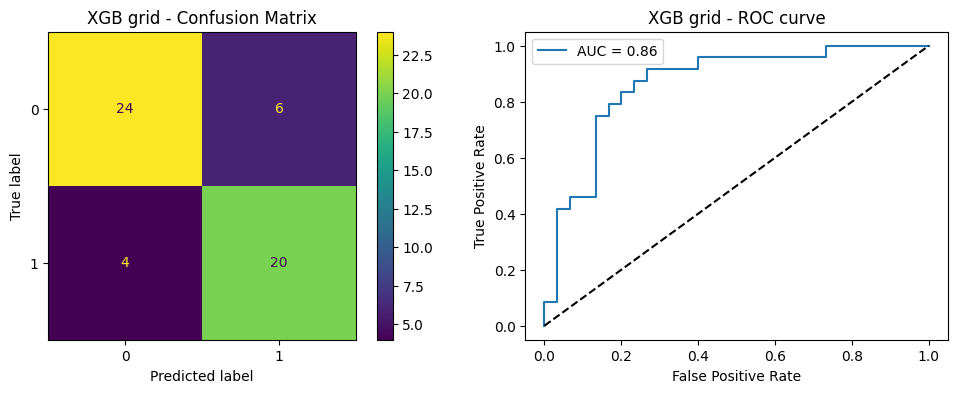

In [154]:
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline([('xgb', XGBClassifier())])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'xgb__n_estimators': [25, 100, 300, 500],
    'xgb__learning_rate': [0.1, 0.5],
    'xgb__max_depth': [3, 5, 7],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1')
grid_xgb.fit(X_train_pre, y_train)
print('Best params: ', grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test_pre, y_test)


## Compare models

In [155]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')
# summary['LR no grid'] = lr_no_gs_metrics
# ... add others you computed ...
summary = {
    'LR no grid': lr_no_gs_metrics,
    'LR grid': lr_gs_metrics,
    'SVM no grid': svm_no_metrics,
    'SVM grid': svm_gs_metrics,
    'XGB no grid': xgb_no_metrics,
    'XGB grid': xgb_gs_metrics,
}

summary_df = pd.DataFrame.from_dict(summary, orient='index')
summary_df


,accuracy,precision,recall,f1,roc_auc
LR no grid,0.8519,0.7857,0.9167,0.8462,0.918056
LR grid,0.8519,0.8077,0.8750,0.8400,0.923611
SVM no grid,0.8889,0.8462,0.9167,0.8800,0.920833
SVM grid,0.8519,0.7857,0.9167,0.8462,0.895833
XGB no grid,0.7963,0.7407,0.8333,0.7843,0.875000
XGB grid,0.8148,0.7692,0.8333,0.8000,0.863889


according to roc_auc value,  the best model is logistic regression with params {'lr__C': 0.1, 'lr__l1_ratio': 0.5, 'lr__max_iter': 10, 'lr__solver': 'saga'} and SVM, both with AUC score above 0.92

for heat disease issue, recall value is very important, because we don't want to miss any positive cases , based on recall and combining with f1 score, SVM is the best model with the highest accuracy, precision and recall, and f1 scores
